In [11]:
import os

import numpy as np

import pandas as pd

import matplotlib.pyplot as mattyp

os.makedirs('../Visualizations', exist_ok=True)


In [12]:
daily_data = pd.read_csv('../data/citibike_weather_daily.csv',
                         header=None,
                         names=["ride_date", 'num_rides','avg_duration_min', 'temp_f', 'max_temp_f','min_temp_f', 'wind_speed_knots', 'precip_in','day_of_week','month'])

In [13]:
daily_data.head()

,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month
0,2013-07-01,16650,16.31,74.8,78.1,73.4,7.8,0.00,Monday,7
1,2013-07-02,22745,15.97,76.1,82.9,73.0,8.0,0.73,Tuesday,7
2,2013-07-03,21864,16.24,78.5,84.9,73.9,8.8,0.06,Wednesday,7
3,2013-07-04,22326,21.22,82.0,91.0,73.9,8.6,0.96,Thursday,7
4,2013-07-05,21842,18.04,84.4,93.0,75.9,9.0,0.00,Friday,7


In [14]:
daily_data.tail()

,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month
1605,2018-05-27,25814,24.00,68.8,91.9,59.0,11.2,0.12,Sunday,5
1606,2018-05-28,49043,22.91,60.2,82.0,55.9,8.3,0.41,Monday,5
1607,2018-05-29,69090,17.07,72.8,87.1,55.9,6.0,0.00,Tuesday,5
1608,2018-05-30,72321,16.62,69.0,87.1,63.0,7.8,0.00,Wednesday,5
1609,2018-05-31,55794,13.87,64.0,77.0,60.1,7.1,0.00,Thursday,5


In [15]:
daily_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ride_date         1610 non-null   object 
 1   num_rides         1610 non-null   int64  
 2   avg_duration_min  1610 non-null   float64
 3   temp_f            1610 non-null   float64
 4   max_temp_f        1610 non-null   float64
 5   min_temp_f        1610 non-null   float64
 6   wind_speed_knots  1610 non-null   float64
 7   precip_in         1610 non-null   float64
 8   day_of_week       1610 non-null   object 
 9   month             1610 non-null   int64  
dtypes: float64(6), int64(2), object(2)
memory usage: 125.9+ KB


In [16]:
daily_data.describe()

,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,month
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,32986.783230,15.425584,57.368509,67.317081,49.295901,9.013913,0.178398,6.544099
std,16910.147968,3.652670,17.876211,18.349408,17.832318,3.241211,2.508762,3.323772
min,876.000000,9.500000,8.300000,18.000000,1.000000,2.300000,0.000000,1.000000
25%,20505.500000,13.112500,43.625000,53.700000,35.700000,6.700000,0.000000,4.000000
50%,32272.500000,14.860000,59.300000,70.000000,51.100000,8.500000,0.000000,7.000000
75%,42915.750000,17.120000,73.500000,82.900000,64.900000,10.800000,0.060000,9.000000
max,78458.000000,81.110000,92.500000,100.900000,82.900000,22.400000,99.990000,12.000000


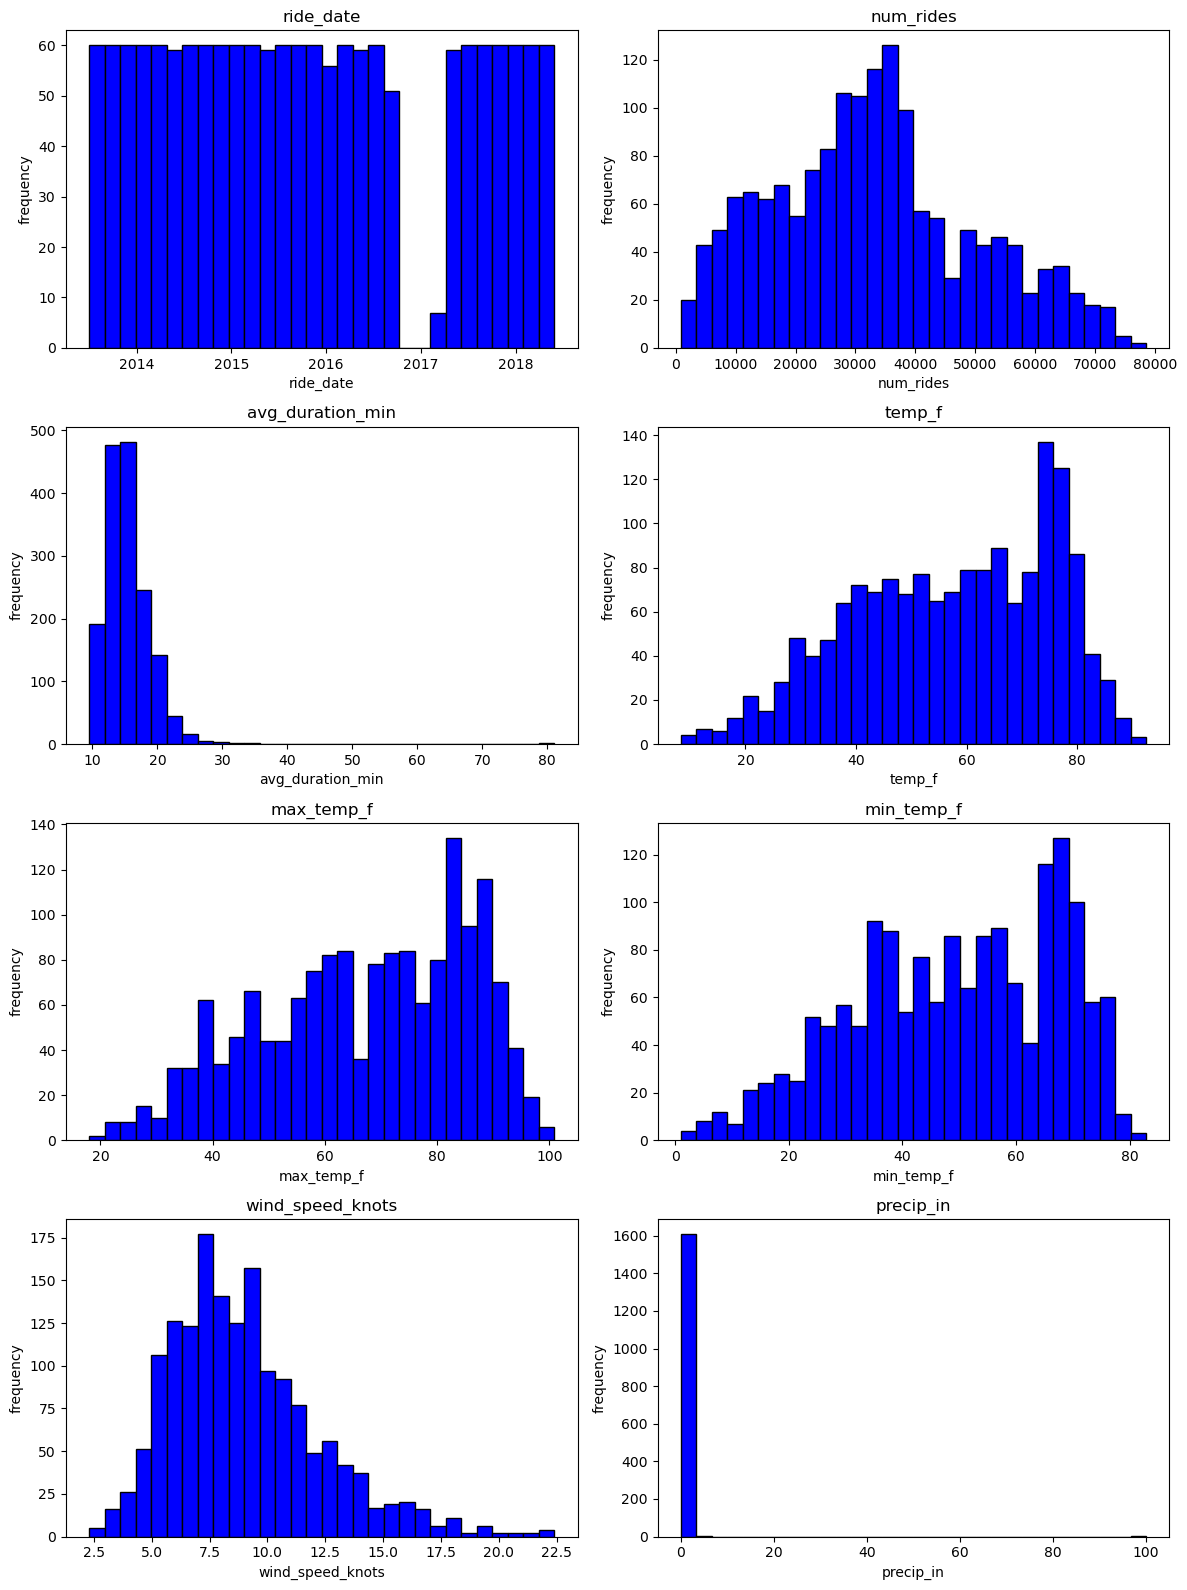

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

In [ ]:
numeric_cols = daily_data.describe().columns
numeric_cols = [col for col in numeric_cols if col != 'month']
fig, axes = mattyp.subplots(nrows=4, ncols=2, figsize=(12, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(daily_data[col], bins=30, color='blue',
edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('frequency')
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
mattyp.tight_layout()
mattyp.savefig('../Visualizations/01histogram_num_colums.png')
mattyp.show()
mattyp.close

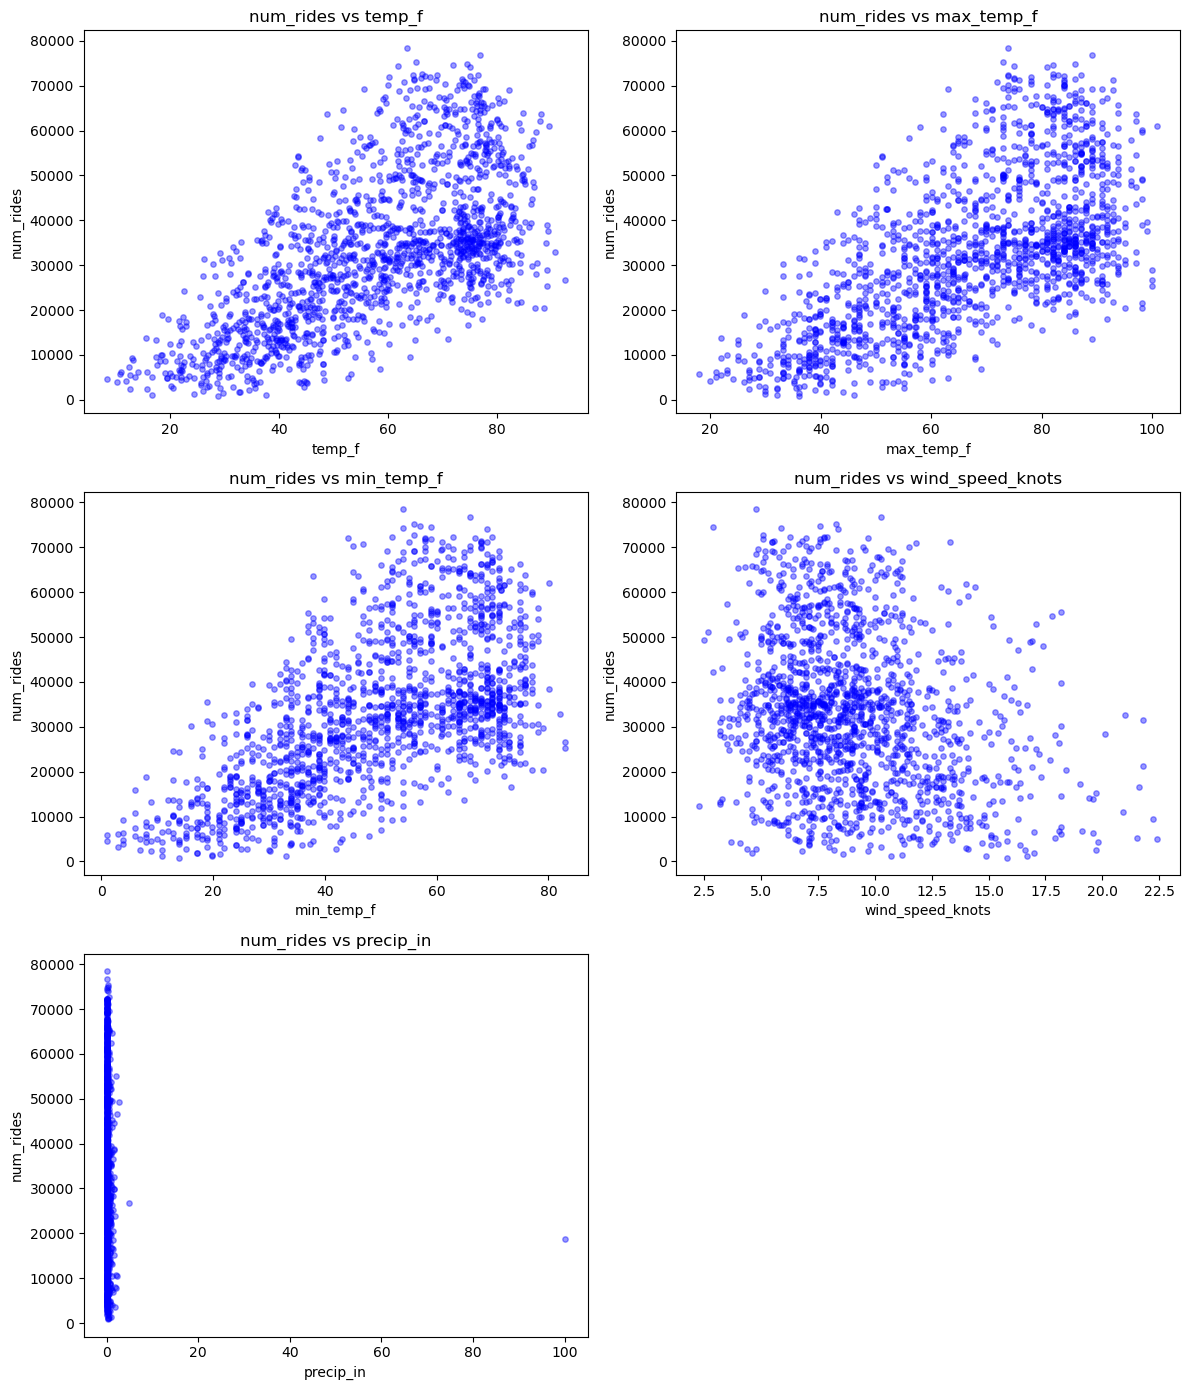

In [18]:
weather_cols = ['temp_f', 'max_temp_f', 'min_temp_f', 'wind_speed_knots', 'precip_in']

fig, axes = mattyp.subplots(nrows=3, ncols=2, figsize=(12, 14))
axes = axes.flatten()

for i, col in enumerate(weather_cols):
    axes[i].scatter(daily_data[col], daily_data['num_rides'], alpha=0.4, s=15, color='blue')
    axes[i].set_title(f'num_rides vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('num_rides')

for j in range(len(weather_cols), len(axes)):
    fig.delaxes(axes[j])

mattyp.tight_layout()
mattyp.savefig('../Visualizations/02scatter_weather_colums.png')
mattyp.show()
mattyp.close()

From the results I would say that number of rides vs winds speeds has a moderate relationship. Ridership tends to be a little higher when wind speeds are lower, but it's pretty noisy, there's a lot of spread in ride counts even at the same wind speed, so wind isn't really driving the pattern on its own. Number of rides vs the tem columns all show the same relationship as the temp rises so does the num of rides, with the highest concentration of rides being at around 80-85 degrees. Ridership does not keep climbing forever it goes up as it got hotter until it hits a certain temperature then it will start to fall off pretty steeply. (Note for feature engineering later).

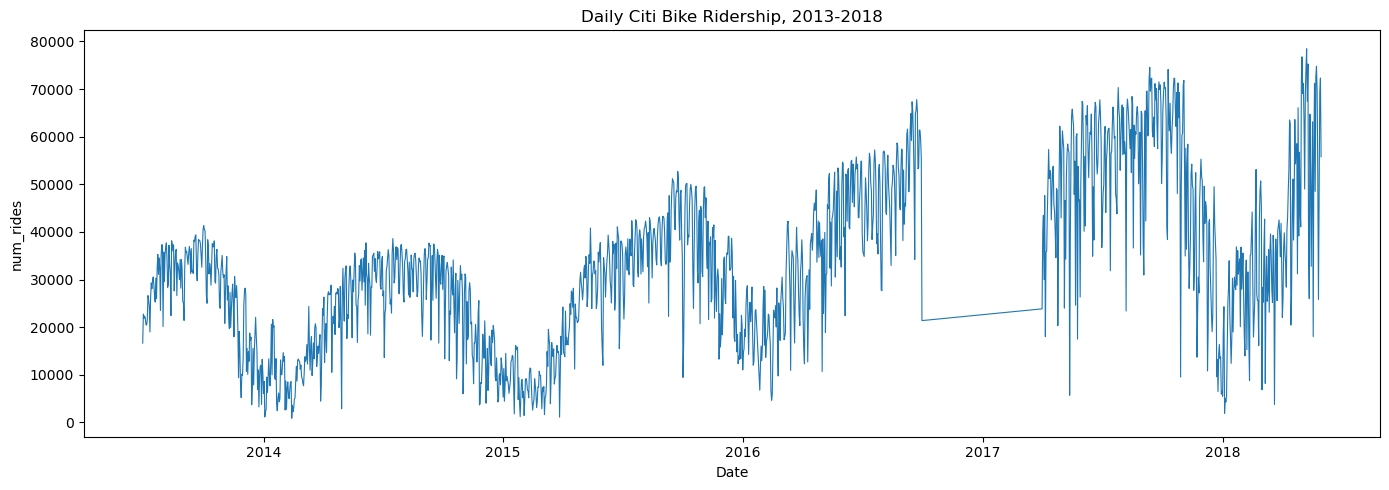

In [22]:
daily_data['ride_date'] = pd.to_datetime(daily_data['ride_date'])

mattyp.figure(figsize=(14, 5))
mattyp.plot(daily_data['ride_date'], daily_data['num_rides'], linewidth=0.8)
mattyp.xlabel('Date')
mattyp.ylabel('num_rides')
mattyp.title(f"Daily Citi Bike Ridership, {daily_data['ride_date'].dt.year.min()}-{daily_data['ride_date'].dt.year.max()}")
mattyp.tight_layout()
mattyp.savefig('../Visualizations/03histogram_num_rides_1317.png')
mattyp.show()
mattyp.close()

I notice similar dips every year but it also seems like ridership is increasing over time. So ridership drops every winter and climbs every summer, consistent with the temperature relationship found in the earlier scatterplot and ridership is increasing year over year. Also there's a flat line in 2017 which concides with the missing rides time period from earlier.

In [23]:
daily_data['year'] = daily_data['ride_date'].dt.year
daily_data['month'] = daily_data['ride_date'].dt.month

july_by_year = daily_data[daily_data['month'] == 7].groupby('year')['num_rides'].mean()
print(july_by_year)

year
2013    27206.967742
2014    31252.967742
2015    35021.806452
2016    44519.677419
2017    55987.064516
Name: num_rides, dtype: float64


Identical weather days in July 2013 and 2017 are not the same. July 2013 averaged 27,206 rides per day while July 2017 averaged 55,987 rides per day a considerable increase. A model with only weather and day of week as inputs would predict the same ridership for both years, since to that model they'd look identical (similar weather and days). The model needs a feature that tells it what year it is, otherwise it has no way to account for the system growing over time (more stations, more bikes, more members).

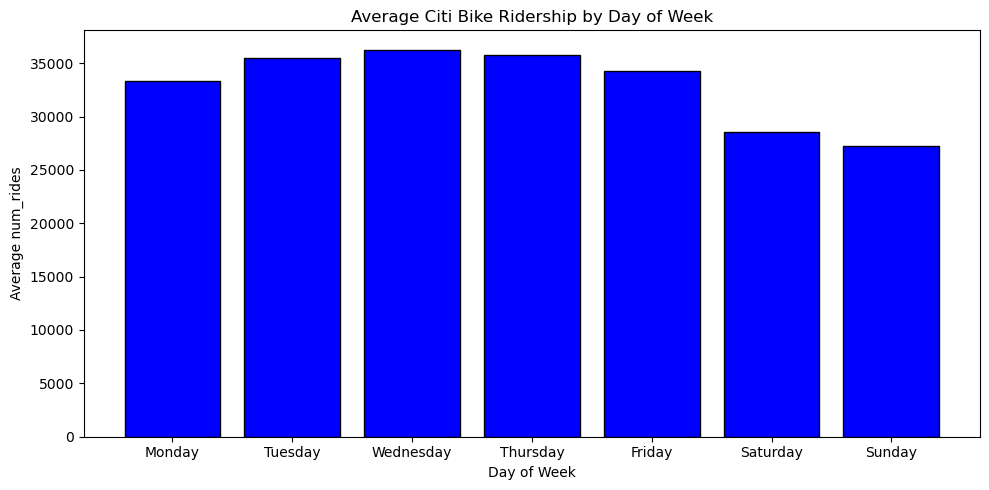

In [24]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

rides_by_day = daily_data.groupby('day_of_week')['num_rides'].mean().reindex(day_order)

mattyp.figure(figsize=(10, 5))
mattyp.bar(rides_by_day.index, rides_by_day.values, color='blue', edgecolor='black')
mattyp.xlabel('Day of Week')
mattyp.ylabel('Average num_rides')
mattyp.title('Average Citi Bike Ridership by Day of Week')
mattyp.tight_layout()
mattyp.show()

Ridership is largely consistent during the week with peaks Wednesday and Thursday. Less riders Saturday and Sunday and this matches my intution because it mimics MTA.

In [25]:
all_dates = pd.date_range(start=daily_data['ride_date'].min(), end=daily_data['ride_date'].max(), freq='D')

actual_dates = pd.to_datetime(daily_data['ride_date'])
missing_dates = all_dates.difference(actual_dates)

print(f"Full date range spans {len(all_dates)} days")
print(f"Data actually has {len(actual_dates)} rows")
print(f"Missing dates: {len(missing_dates)}")
print(missing_dates)

Full date range spans 1796 days
Data actually has 1610 rows
Missing dates: 186
DatetimeIndex(['2016-01-23', '2016-01-24', '2016-01-25', '2016-01-26',
               '2016-10-01', '2016-10-02', '2016-10-03', '2016-10-04',
               '2016-10-05', '2016-10-06',
               ...
               '2017-03-22', '2017-03-23', '2017-03-24', '2017-03-25',
               '2017-03-26', '2017-03-27', '2017-03-28', '2017-03-29',
               '2017-03-30', '2017-03-31'],
              dtype='datetime64[ns]', length=186, freq=None)


In [26]:
gap_daily_data = pd.DataFrame({'missing_date': missing_dates})
gap_daily_data['gap_id'] = (gap_daily_data['missing_date'].diff() != pd.Timedelta('1 day')).cumsum()

gap_summary = gap_daily_data.groupby('gap_id')['missing_date'].agg(['min', 'max', 'count'])
print(gap_summary)

              min        max  count
gap_id                             
1      2016-01-23 2016-01-26      4
2      2016-10-01 2017-03-31    182


There are acutally two gaps in the data not one; a 4 day gap from January 23-26, 2016, and a much larger 182 day gap from October 1, 2016 through March 31, 2017 (186 missing days total). Since Part 1's query is an inner join between daily_rides (from citibike_trips) and daily_weather (NOAA station 725030, LaGuardia Airport), a missing date means at least one side had no row for that day. LaGuardia is a major, continuously operating station, so a 182 day gap from the weather side would be unusual and well documented. That points to the ridership side of the join as the more likely source of the gaps, rather than the weather data.